## Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    accuracy_score, f1_score, recall_score
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import warnings
import urllib.request
import chardet
warnings.filterwarnings('ignore')


## Data Loading

In [ ]:
# Check Encoding

hr_paths = [
    'https://drive.google.com/uc?export=download&id=1Sacvu28-LXCn4s5H2RpKZ9pa4N-fec7w',
    'https://drive.google.com/uc?export=download&id=1dQpIwxNbkOedl4xeCtBKNp2vmUUJWBvU',
    'https://drive.google.com/uc?export=download&id=1n7mDiiA6dAa1cXUQrwztVb6uRx8Zr0Tg',
    'https://drive.google.com/uc?export=download&id=1Qhda2lDTKpHCv0_tYjj-xznJsIwHydCI',
    'https://drive.google.com/uc?export=download&id=1jyWIR9bfjuoaMLLRoVFbefl3W_6MCutF'
]

for file in hr_paths:
    try:
        with urllib.request.urlopen(file) as response:
            rawdata = response.read(10000)
            result = chardet.detect(rawdata)
        print(f"Detected Encoding for {file}: {result['encoding']}")
    except Exception as e:
        print(f"Failed to stream from URL. Error: {e}")

Detected Encoding for https://drive.google.com/uc?export=download&id=1Sacvu28-LXCn4s5H2RpKZ9pa4N-fec7w: ascii
Detected Encoding for https://drive.google.com/uc?export=download&id=1dQpIwxNbkOedl4xeCtBKNp2vmUUJWBvU: ascii
Detected Encoding for https://drive.google.com/uc?export=download&id=1n7mDiiA6dAa1cXUQrwztVb6uRx8Zr0Tg: ascii
Detected Encoding for https://drive.google.com/uc?export=download&id=1Qhda2lDTKpHCv0_tYjj-xznJsIwHydCI: ascii
Detected Encoding for https://drive.google.com/uc?export=download&id=1jyWIR9bfjuoaMLLRoVFbefl3W_6MCutF: ascii


In [ ]:
employee_survey_data = pd.read_csv('https://drive.google.com/uc?export=download&id=1Sacvu28-LXCn4s5H2RpKZ9pa4N-fec7w')
general_data = pd.read_csv('https://drive.google.com/uc?export=download&id=1dQpIwxNbkOedl4xeCtBKNp2vmUUJWBvU')
in_time = pd.read_csv('https://drive.google.com/uc?export=download&id=1n7mDiiA6dAa1cXUQrwztVb6uRx8Zr0Tg')  # rows=EmployeeID, cols=dates
manager_survey_data = pd.read_csv('https://drive.google.com/uc?export=download&id=1Qhda2lDTKpHCv0_tYjj-xznJsIwHydCI')
out_time = pd.read_csv('https://drive.google.com/uc?export=download&id=1jyWIR9bfjuoaMLLRoVFbefl3W_6MCutF')

In [ ]:
employee_survey_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4410 non-null   int64  
 1   EnvironmentSatisfaction  4385 non-null   float64
 2   JobSatisfaction          4390 non-null   float64
 3   WorkLifeBalance          4372 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 137.9 KB


In [ ]:
general_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

In [ ]:
in_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Columns: 262 entries, Unnamed: 0 to 2015-12-31
dtypes: float64(12), int64(1), object(249)
memory usage: 8.8+ MB


In [ ]:
in_time.head()

,Unnamed: 0,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,1,NaN,2015-01-02 09:43:45,2015-01-05 10:08:48,2015-01-06 09:54:26,2015-01-07 09:34:31,2015-01-08 09:51:09,2015-01-09 10:09:25,2015-01-12 09:42:53,2015-01-13 10:13:06,...,NaN,2015-12-21 09:55:29,2015-12-22 10:04:06,2015-12-23 10:14:27,2015-12-24 10:11:35,NaN,2015-12-28 10:13:41,2015-12-29 10:03:36,2015-12-30 09:54:12,2015-12-31 10:12:44
1,2,NaN,2015-01-02 10:15:44,2015-01-05 10:21:05,NaN,2015-01-07 09:45:17,2015-01-08 10:09:04,2015-01-09 09:43:26,2015-01-12 10:00:07,2015-01-13 10:43:29,...,2015-12-18 10:37:17,2015-12-21 09:49:02,2015-12-22 10:33:51,2015-12-23 10:12:10,NaN,NaN,2015-12-28 09:31:45,2015-12-29 09:55:49,2015-12-30 10:32:25,2015-12-31 09:27:20
2,3,NaN,2015-01-02 10:17:41,2015-01-05 09:50:50,2015-01-06 10:14:13,2015-01-07 09:47:27,2015-01-08 10:03:40,2015-01-09 10:05:49,2015-01-12 10:03:47,2015-01-13 10:21:26,...,2015-12-18 10:15:14,2015-12-21 10:10:28,2015-12-22 09:44:44,2015-12-23 10:15:54,2015-12-24 10:07:26,NaN,2015-12-28 09:42:05,2015-12-29 09:43:36,2015-12-30 09:34:05,2015-12-31 10:28:39
3,4,NaN,2015-01-02 10:05:06,2015-01-05 09:56:32,2015-01-06 10:11:07,2015-01-07 09:37:30,2015-01-08 10:02:08,2015-01-09 10:08:12,2015-01-12 10:13:42,2015-01-13 09:53:22,...,2015-12-18 10:17:38,2015-12-21 09:58:21,2015-12-22 10:04:25,2015-12-23 10:11:46,2015-12-24 09:43:15,NaN,2015-12-28 09:52:44,2015-12-29 09:33:16,2015-12-30 10:18:12,2015-12-31 10:01:15
4,5,NaN,2015-01-02 10:28:17,2015-01-05 09:49:58,2015-01-06 09:45:28,2015-01-07 09:49:37,2015-01-08 10:19:44,2015-01-09 10:00:50,2015-01-12 10:29:27,2015-01-13 09:59:32,...,2015-12-18 09:58:35,2015-12-21 10:03:41,2015-12-22 10:10:30,2015-12-23 10:13:36,2015-12-24 09:44:24,NaN,2015-12-28 10:05:15,2015-12-29 10:30:53,2015-12-30 09:18:21,2015-12-31 09:41:09


In [ ]:
manager_survey_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   EmployeeID         4410 non-null   int64
 1   JobInvolvement     4410 non-null   int64
 2   PerformanceRating  4410 non-null   int64
dtypes: int64(3)
memory usage: 103.5 KB


In [ ]:
out_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Columns: 262 entries, Unnamed: 0 to 2015-12-31
dtypes: float64(12), int64(1), object(249)
memory usage: 8.8+ MB


In [ ]:
out_time.head()

,Unnamed: 0,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,1,NaN,2015-01-02 16:56:15,2015-01-05 17:20:11,2015-01-06 17:19:05,2015-01-07 16:34:55,2015-01-08 17:08:32,2015-01-09 17:38:29,2015-01-12 16:58:39,2015-01-13 18:02:58,...,NaN,2015-12-21 17:15:50,2015-12-22 17:27:51,2015-12-23 16:44:44,2015-12-24 17:47:22,NaN,2015-12-28 18:00:07,2015-12-29 17:22:30,2015-12-30 17:40:56,2015-12-31 17:17:33
1,2,NaN,2015-01-02 18:22:17,2015-01-05 17:48:22,NaN,2015-01-07 17:09:06,2015-01-08 17:34:04,2015-01-09 16:52:29,2015-01-12 17:36:48,2015-01-13 18:00:13,...,2015-12-18 18:31:28,2015-12-21 17:34:16,2015-12-22 18:16:35,2015-12-23 17:38:18,NaN,NaN,2015-12-28 17:08:38,2015-12-29 17:54:46,2015-12-30 18:31:35,2015-12-31 17:40:58
2,3,NaN,2015-01-02 16:59:14,2015-01-05 17:06:46,2015-01-06 16:38:32,2015-01-07 16:33:21,2015-01-08 17:24:22,2015-01-09 16:57:30,2015-01-12 17:28:54,2015-01-13 17:21:25,...,2015-12-18 17:02:23,2015-12-21 17:20:17,2015-12-22 16:32:50,2015-12-23 16:59:43,2015-12-24 16:58:25,NaN,2015-12-28 16:43:31,2015-12-29 17:09:56,2015-12-30 17:06:25,2015-12-31 17:15:50
3,4,NaN,2015-01-02 17:25:24,2015-01-05 17:14:03,2015-01-06 17:07:42,2015-01-07 16:32:40,2015-01-08 16:53:11,2015-01-09 17:19:47,2015-01-12 17:13:37,2015-01-13 17:11:45,...,2015-12-18 17:55:23,2015-12-21 16:49:09,2015-12-22 17:24:00,2015-12-23 17:36:35,2015-12-24 16:48:21,NaN,2015-12-28 17:19:34,2015-12-29 16:58:16,2015-12-30 17:40:11,2015-12-31 17:09:14
4,5,NaN,2015-01-02 18:31:37,2015-01-05 17:49:15,2015-01-06 17:26:25,2015-01-07 17:37:59,2015-01-08 17:59:28,2015-01-09 17:44:08,2015-01-12 18:51:21,2015-01-13 18:14:58,...,2015-12-18 17:52:48,2015-12-21 17:43:35,2015-12-22 18:07:57,2015-12-23 18:00:49,2015-12-24 17:59:22,NaN,2015-12-28 17:44:59,2015-12-29 18:47:00,2015-12-30 17:15:33,2015-12-31 17:42:14


### Merge DataFrame

In [ ]:
# Identify relationships
hr_files = [employee_survey_data, general_data, manager_survey_data]

common_keys = None

for file in hr_files:
    try:
        df = file
        cols = set(df.columns)

        if common_keys is None:
              common_keys = cols

        else:
            common_keys = common_keys.intersection(cols)

    except Exception as e:
        print(f" Error checking {file}: {e}")

print("Common Keys for HR Data:", common_keys)

Common Keys for HR Data: {'EmployeeID'}


In [ ]:
# Merge dataframe
df_combined = pd.merge(employee_survey_data, general_data, on='EmployeeID', how='inner')
df_combined2 = pd.merge(df_combined, manager_survey_data, on='EmployeeID', how='inner')

## Data Cleaning & Processing

### Rename columns

In [ ]:
in_time = in_time.rename(columns={'Unnamed: 0': 'EmployeeID'})
out_time = out_time.rename(columns={'Unnamed: 0': 'EmployeeID'})

### Convert date columns to Datetime values

In [ ]:
in_time_date = in_time.drop(columns=['EmployeeID']).apply(pd.to_datetime, errors='coerce')
out_time_date = out_time.drop(columns=['EmployeeID']).apply(pd.to_datetime, errors='coerce')
in_time = pd.concat([in_time['EmployeeID'], in_time_date], axis=1)
out_time = pd.concat([out_time['EmployeeID'], out_time_date], axis=1)

In [ ]:
# Calculate work duration
in_time.set_index('EmployeeID', inplace=True)
out_time.set_index('EmployeeID', inplace=True)
work_duration = out_time - in_time
work_hour = work_duration.apply(lambda x: x.dt.total_seconds() / 3600)
work_hour.head()

,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,2015-01-14,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
EmployeeID,,,,,,,,,,,,,,,,,,,,,
1,NaN,7.208333,7.189722,7.410833,7.006667,7.289722,7.484444,7.262778,7.831111,NaN,...,NaN,7.339167,7.395833,6.504722,7.596389,NaN,7.773889,7.315000,7.778889,7.080278
2,NaN,8.109167,7.454722,NaN,7.396944,7.416667,7.150833,7.611389,7.278889,NaN,...,7.903056,7.753889,7.712222,7.435556,NaN,NaN,7.614722,7.982500,7.986111,8.227222
3,NaN,6.692500,7.265556,6.405278,6.765000,7.345000,6.861389,7.418611,6.999722,NaN,...,6.785833,7.163611,6.801667,6.730278,6.849722,NaN,7.023889,7.438889,7.538889,6.786389
4,NaN,7.338333,7.291944,6.943056,6.919444,6.850833,7.193056,6.998611,7.306389,NaN,...,7.629167,6.846667,7.326389,7.413611,7.085000,NaN,7.447222,7.416667,7.366389,7.133056
5,NaN,8.055556,7.988056,7.682500,7.806111,7.662222,7.721667,8.365000,8.257222,NaN,...,7.903611,7.665000,7.957500,7.786944,8.249444,NaN,7.662222,8.268611,7.953333,8.018056


### Handle missing data

In [ ]:
df_combined2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4410 non-null   int64  
 1   EnvironmentSatisfaction  4385 non-null   float64
 2   JobSatisfaction          4390 non-null   float64
 3   WorkLifeBalance          4372 non-null   float64
 4   Age                      4410 non-null   int64  
 5   Attrition                4410 non-null   object 
 6   BusinessTravel           4410 non-null   object 
 7   Department               4410 non-null   object 
 8   DistanceFromHome         4410 non-null   int64  
 9   Education                4410 non-null   int64  
 10  EducationField           4410 non-null   object 
 11  EmployeeCount            4410 non-null   int64  
 12  Gender                   4410 non-null   object 
 13  JobLevel                 4410 non-null   int64  
 14  JobRole                 

In [ ]:
df_combined2.describe()

,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Age,DistanceFromHome,Education,EmployeeCount,JobLevel,MonthlyIncome,...,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,JobInvolvement,PerformanceRating
count,4410.000000,4385.000000,4390.000000,4372.000000,4410.000000,4410.000000,4410.000000,4410.0,4410.000000,4410.000000,...,4410.000000,4410.0,4410.000000,4401.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000
mean,2205.500000,2.723603,2.728246,2.761436,36.923810,9.192517,2.912925,1.0,2.063946,65029.312925,...,15.209524,8.0,0.793878,11.279936,2.799320,7.008163,2.187755,4.123129,2.729932,3.153741
std,1273.201673,1.092756,1.101253,0.706245,9.133301,8.105026,1.023933,0.0,1.106689,47068.888559,...,3.659108,0.0,0.851883,7.782222,1.288978,6.125135,3.221699,3.567327,0.711400,0.360742
min,1.000000,1.000000,1.000000,1.000000,18.000000,1.000000,1.000000,1.0,1.000000,10090.000000,...,11.000000,8.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000
25%,1103.250000,2.000000,2.000000,2.000000,30.000000,2.000000,2.000000,1.0,1.000000,29110.000000,...,12.000000,8.0,0.000000,6.000000,2.000000,3.000000,0.000000,2.000000,2.000000,3.000000
50%,2205.500000,3.000000,3.000000,3.000000,36.000000,7.000000,3.000000,1.0,2.000000,49190.000000,...,14.000000,8.0,1.000000,10.000000,3.000000,5.000000,1.000000,3.000000,3.000000,3.000000
75%,3307.750000,4.000000,4.000000,3.000000,43.000000,14.000000,4.000000,1.0,3.000000,83800.000000,...,18.000000,8.0,1.000000,15.000000,3.000000,9.000000,3.000000,7.000000,3.000000,3.000000
max,4410.000000,4.000000,4.000000,4.000000,60.000000,29.000000,5.000000,1.0,5.000000,199990.000000,...,25.000000,8.0,3.000000,40.000000,6.000000,40.000000,15.000000,17.000000,4.000000,4.000000


In [ ]:
# Drop columns where all values are NaN
work_hour = work_hour.dropna(axis=0, how='all')

# Fill missing values with mean
work_hour = work_hour.T.fillna(work_hour.mean(axis=1)).T
df_combined2['WorkLifeBalance'] = df_combined2['WorkLifeBalance'].fillna(df_combined2['WorkLifeBalance'].mean())
df_combined2['EnvironmentSatisfaction'] = df_combined2['EnvironmentSatisfaction'].fillna(df_combined2['EnvironmentSatisfaction'].mean())
df_combined2['JobSatisfaction'] = df_combined2['JobSatisfaction'].fillna(df_combined2['JobSatisfaction'].mean())

#Drop row with atleast 1 Nan
df_combined2 = df_combined2.dropna()

In [ ]:
# Get average work hours per row
work_hour_mean = work_hour.mean(axis=1).to_frame('AvgWorkHours')

# Add new column
df_final = df_combined2.merge(
    work_hour_mean,
    left_on='EmployeeID',
    right_index=True,
    how='left'
)

absent_days = work_hour.isnull().sum(axis=1).to_frame('AbsentDays')
df_final = df_final.merge(absent_days, left_on='EmployeeID', right_index=True, how='left')

### Drop Duplicates

In [ ]:
df_final = df_final.drop_duplicates(subset=['EmployeeID'])
cols_to_drop_duplicate = [col for col in df_final.columns if df_final[col].nunique() <= 1]
print(cols_to_drop_duplicate)
df_final = df_final.drop(columns=cols_to_drop_duplicate)
df_final.info()

['EmployeeCount', 'Over18', 'StandardHours', 'AbsentDays']
<class 'pandas.core.frame.DataFrame'>
Index: 4382 entries, 0 to 4408
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4382 non-null   int64  
 1   EnvironmentSatisfaction  4382 non-null   float64
 2   JobSatisfaction          4382 non-null   float64
 3   WorkLifeBalance          4382 non-null   float64
 4   Age                      4382 non-null   int64  
 5   Attrition                4382 non-null   object 
 6   BusinessTravel           4382 non-null   object 
 7   Department               4382 non-null   object 
 8   DistanceFromHome         4382 non-null   int64  
 9   Education                4382 non-null   int64  
 10  EducationField           4382 non-null   object 
 11  Gender                   4382 non-null   object 
 12  JobLevel                 4382 non-null   int64  
 13  JobRole                 

### Variable Encoding

In [ ]:
df_model = df_final.copy()
cat_cols = df_model.select_dtypes(include=['object']).columns.tolist()

encoders = {}
for col in cat_cols:
    encoders[col] = LabelEncoder()
    df_model[col] = encoders[col].fit_transform(df_model[col].astype(str))

In [ ]:
df_model.head()

,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,...,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,JobInvolvement,PerformanceRating,AvgWorkHours
0,1,3.0,4.0,2.0,51,0,2,2,6,2,...,11,0,1.0,6,1,0,0,3,3,7.373651
1,2,3.0,2.0,4.0,31,1,1,1,10,1,...,23,1,6.0,3,5,1,4,2,4,7.718969
2,3,2.0,2.0,1.0,32,0,1,1,17,4,...,15,3,5.0,2,5,0,3,3,3,7.013240
3,4,4.0,4.0,3.0,38,0,0,1,2,5,...,11,3,13.0,5,8,7,5,2,3,7.193678
4,5,4.0,1.0,3.0,32,0,2,1,10,1,...,12,2,9.0,2,6,0,4,3,3,8.006175


## Exploratory Data Analysis (EDA)

### 1. Target Variable — Attrition Distribution

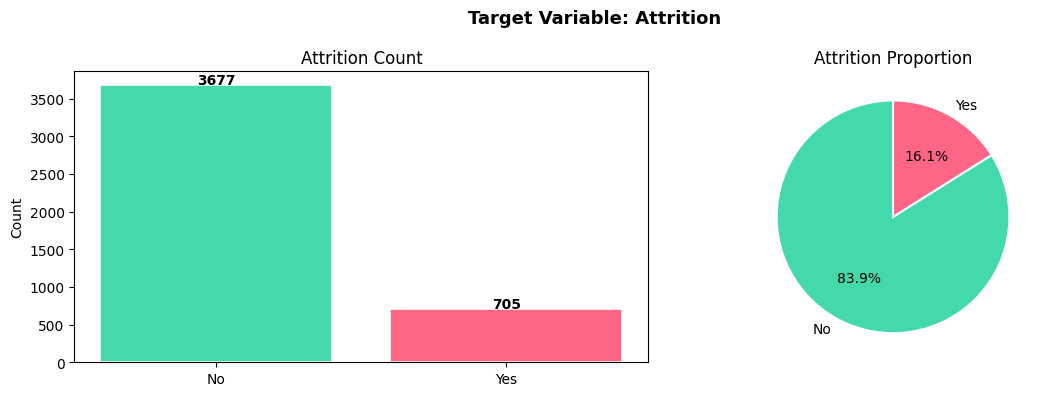


Note: Class imbalance detected — use class_weight or F1/AUC metrics.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

attrition_counts = df_final['Attrition'].value_counts()
axes[0].bar(attrition_counts.index, attrition_counts.values,
            color=['#43d9ad', '#ff6584'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Attrition Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(attrition_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].pie(attrition_counts, labels=attrition_counts.index,
            autopct='%1.1f%%', colors=['#43d9ad', '#ff6584'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Attrition Proportion')

plt.suptitle('Target Variable: Attrition', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("\nNote: Class imbalance detected — use class_weight or F1/AUC metrics.")

### 2. Boxplots — Numerical Features vs Attrition

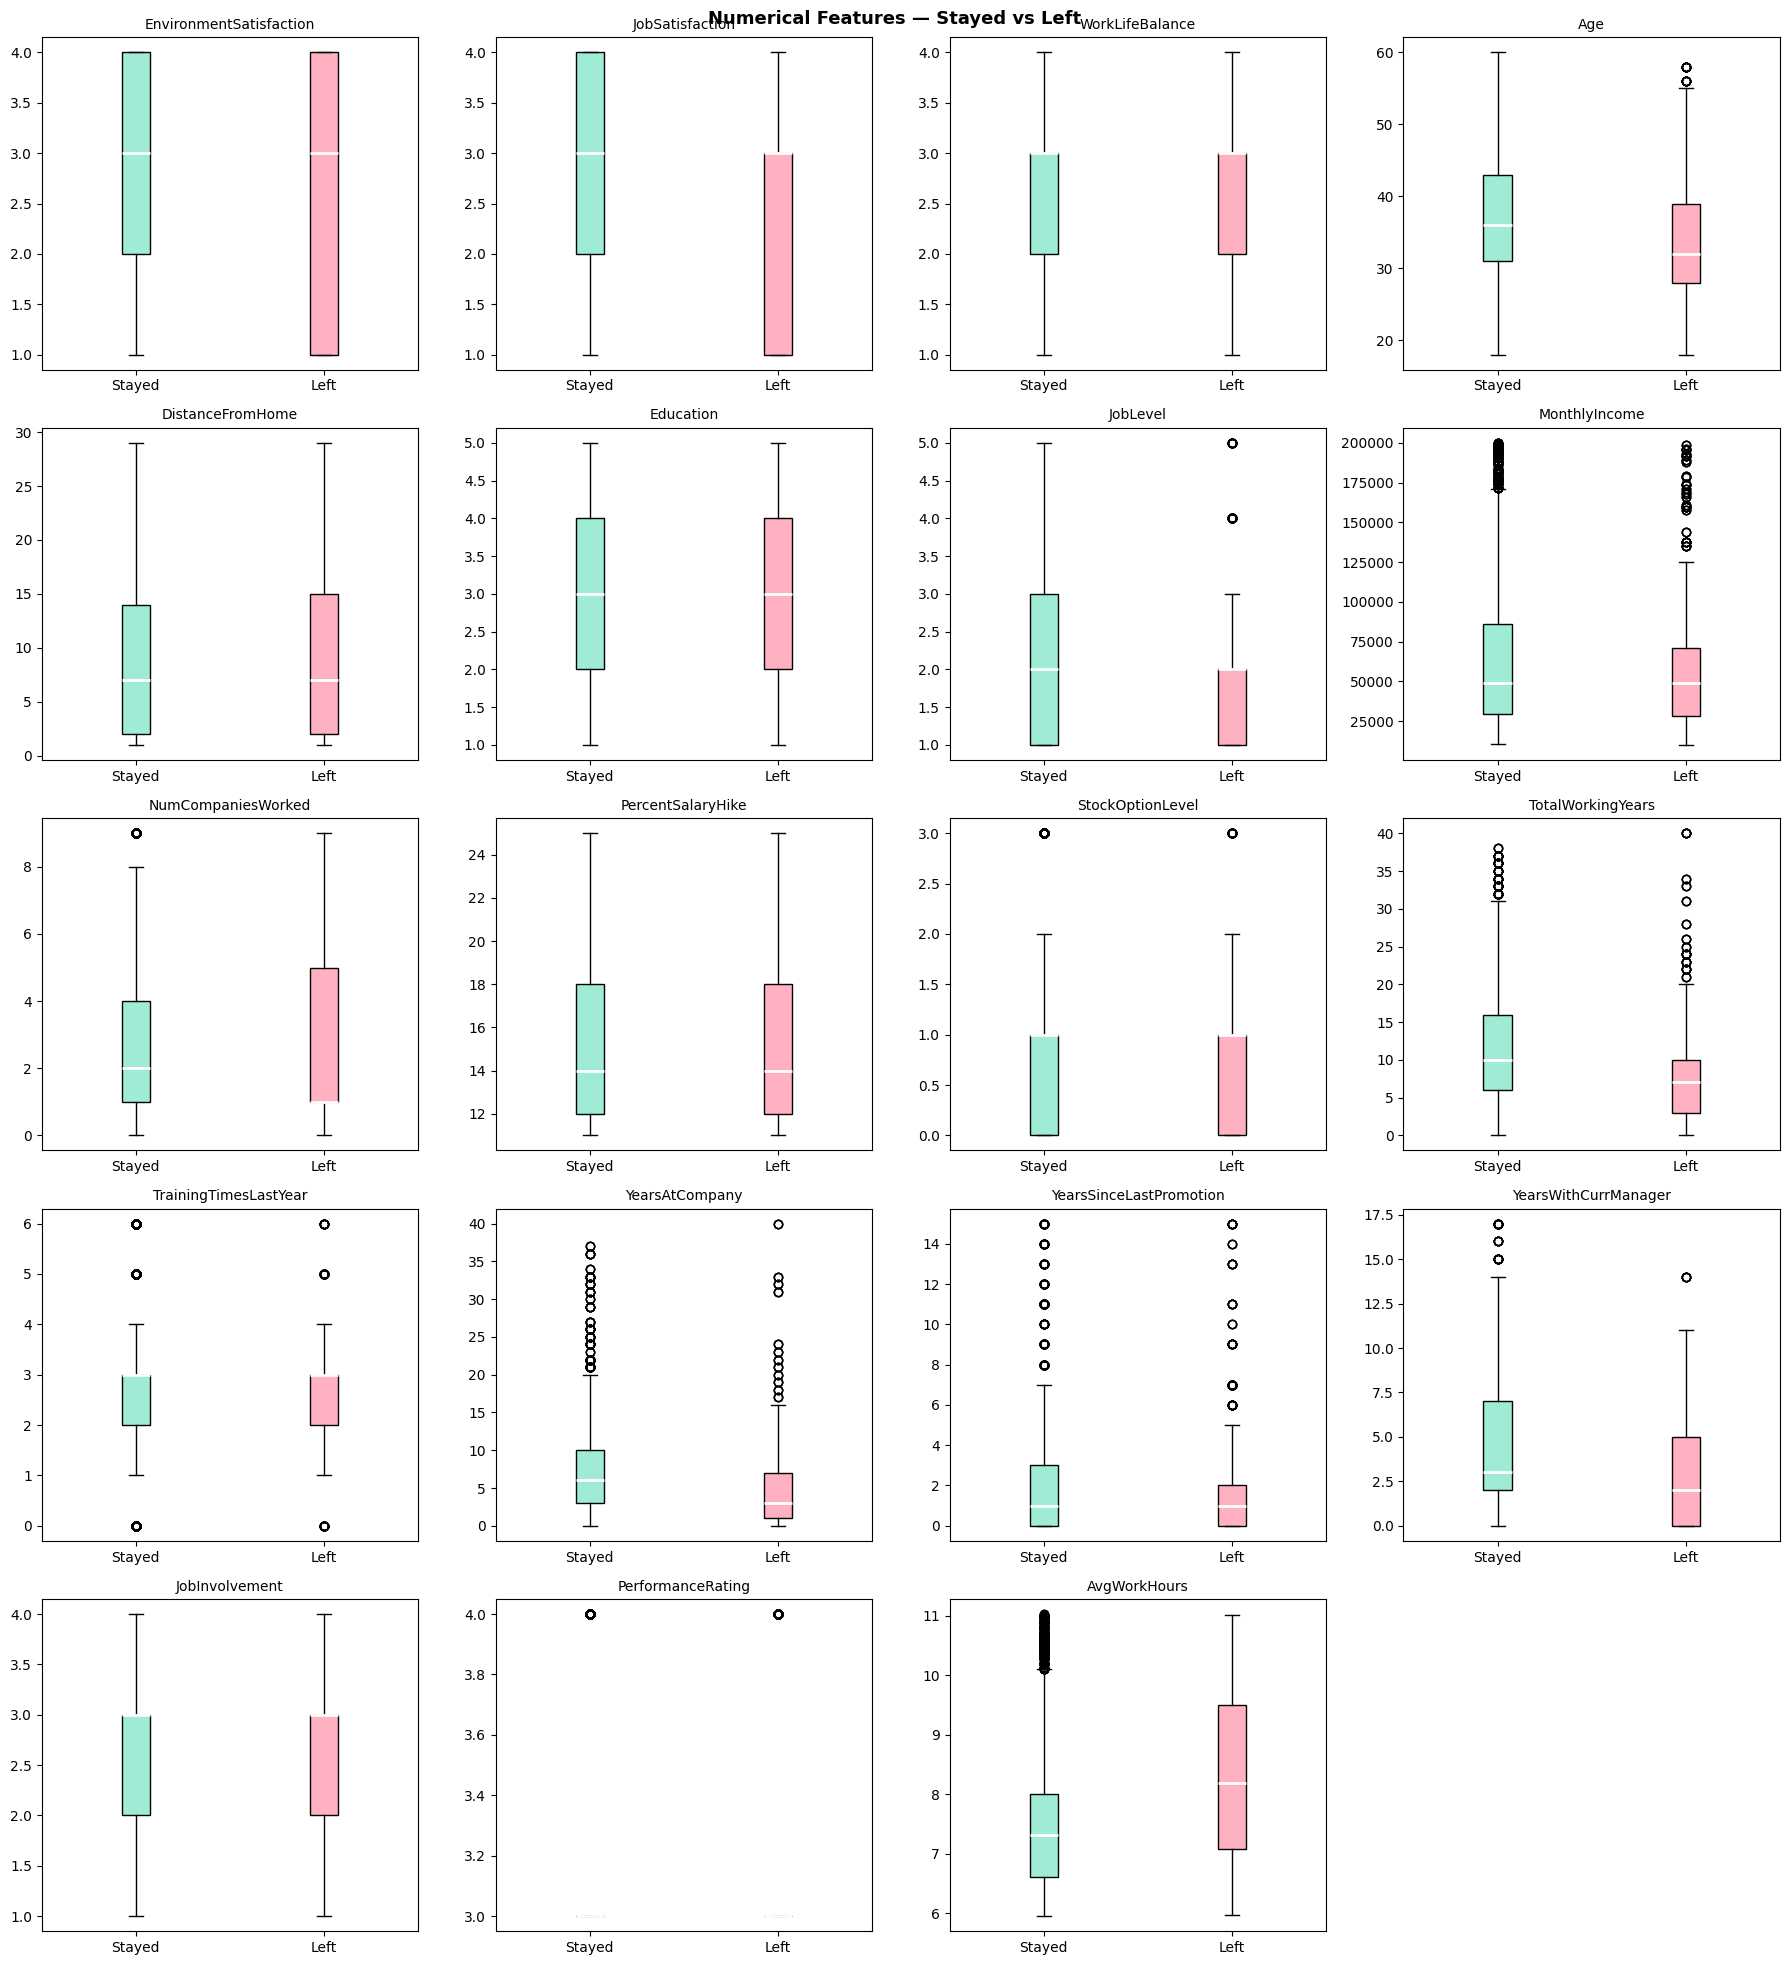

In [ ]:
num_cols = df_final.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c not in ['EmployeeID']]

n = len(num_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data_no  = df_final[df_final['Attrition'] == 'No'][col].dropna()
    data_yes = df_final[df_final['Attrition'] == 'Yes'][col].dropna()
    bp = axes[i].boxplot([data_no, data_yes], labels=['Stayed', 'Left'],
                         patch_artist=True,
                         medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set_facecolor('#43d9ad80')
    bp['boxes'][1].set_facecolor('#ff658480')
    axes[i].set_title(col, fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features — Stayed vs Left', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. Attrition Rate by Categorical Features

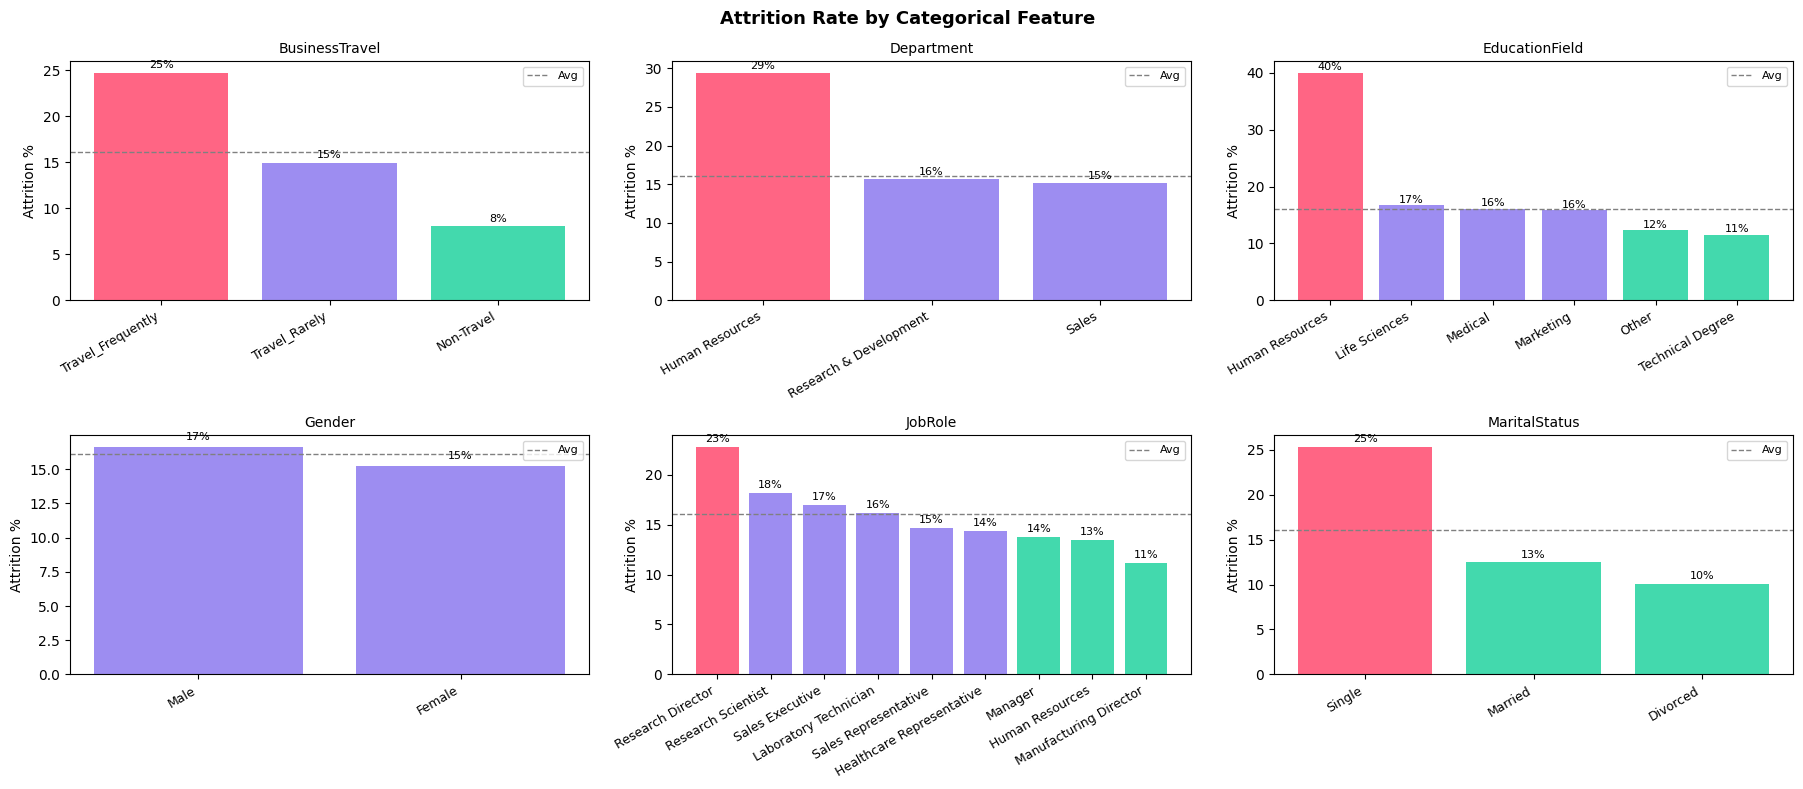

In [ ]:
cat_cols_orig = df_final.select_dtypes(include='object').columns.tolist()
cat_cols_orig = [c for c in cat_cols_orig if c != 'Attrition']

if cat_cols_orig:
    df_final['_attr_bin'] = (df_final['Attrition'] == 'Yes').astype(int)
    ncols = 3
    nrows = (len(cat_cols_orig) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols_orig):
        rates = df_final.groupby(col)['_attr_bin'].mean().sort_values(ascending=False) * 100
        colors = ['#ff6584' if v > 20 else '#9d8df1' if v > 14 else '#43d9ad'
                  for v in rates.values]
        axes[i].bar(range(len(rates)), rates.values, color=colors)
        axes[i].set_xticks(range(len(rates)))
        axes[i].set_xticklabels(rates.index, rotation=30, ha='right', fontsize=9)
        axes[i].set_title(f'{col}', fontsize=10)
        axes[i].set_ylabel('Attrition %')
        axes[i].axhline(df_final['_attr_bin'].mean() * 100,
                        color='gray', linestyle='--', linewidth=1, label='Avg')
        for j, v in enumerate(rates.values):
            axes[i].text(j, v + 0.5, f'{v:.0f}%', ha='center', fontsize=8)
        axes[i].legend(fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    try:
        df_final.drop(columns=['_attr_bin'], inplace=True)
    finally:
        pass

    plt.suptitle('Attrition Rate by Categorical Feature', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No raw categorical columns found — already encoded.")

### 4. Correlation Heatmap

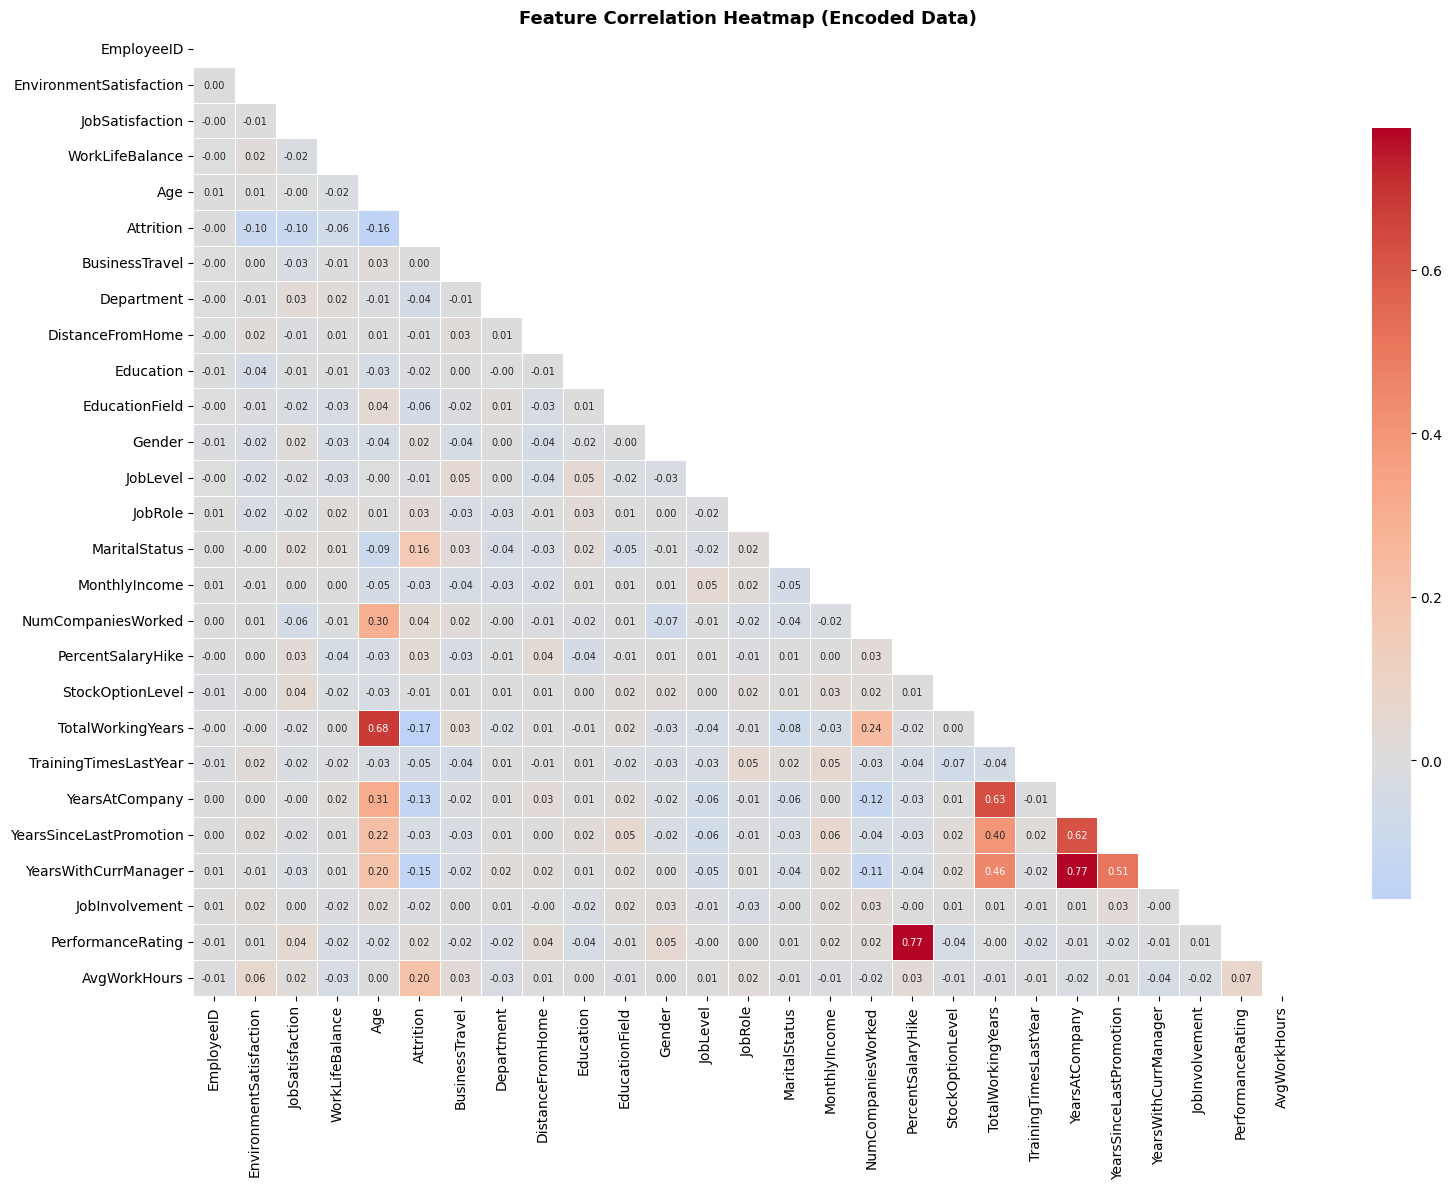

In [ ]:
num_model_cols = df_model.select_dtypes(include='number').columns.tolist()
corr = df_model[num_model_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap (Encoded Data)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 5. Feature Correlation with Attrition

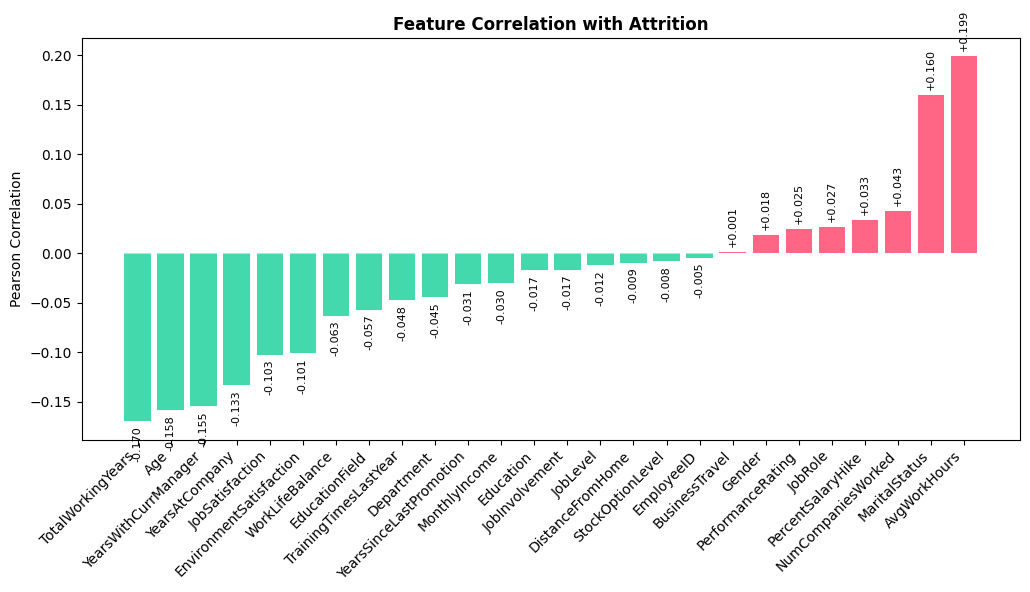


Top positive risk factors (increase attrition):
JobRole               0.026708
PercentSalaryHike     0.033153
NumCompaniesWorked    0.042831
MaritalStatus         0.160081
AvgWorkHours          0.198876

Top protective factors (reduce attrition):
TotalWorkingYears      -0.169670
Age                    -0.158399
YearsWithCurrManager   -0.154692
YearsAtCompany         -0.133003
JobSatisfaction        -0.102614


In [ ]:
corr_target = df_model[num_model_cols].corr()['Attrition'].drop('Attrition').sort_values()

colors = ['#ff6584' if v > 0 else '#43d9ad' for v in corr_target.values]
fig, ax = plt.subplots(figsize=(max(8, len(corr_target) * 0.4), 6))
ax.bar(corr_target.index, corr_target.values, color=colors)
ax.axhline(0, color='white', linewidth=0.8, alpha=0.5)

ax.set_title('Feature Correlation with Attrition', fontsize=12, fontweight='bold')
ax.set_ylabel('Pearson Correlation')

plt.xticks(rotation=45, ha='right')

for i, v in enumerate(corr_target.values):
    ax.text(i, v + (0.005 if v >= 0 else -0.005),
            f'{v:+.3f}',
            ha='center',
            va='bottom' if v >= 0 else 'top',
            fontsize=8,
            rotation=90)

plt.tight_layout()
plt.show()

print("\nTop positive risk factors (increase attrition):")
print(corr_target[corr_target > 0].tail(5).to_string())
print("\nTop protective factors (reduce attrition):")
print(corr_target[corr_target < 0].head(5).to_string())

### 6. FEATURE SELECTION / TARGET SPLIT

In [ ]:
cols_to_drop = [
    'BusinessTravel',
    'StockOptionLevel',
    'DistanceFromHome',
    'JobLevel',
    'EmployeeID',
    'Attrition'
]

feature_cols = [c for c in df_model.columns if c not in cols_to_drop]
X = df_model[feature_cols]
y = df_model['Attrition']

## Implementing Machine Learning Algorithms

In [ ]:
# TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# SCALING (For SVM & Neural Network)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic Regression (Baseline)": {
        "model": LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        ),
        "scaled": True
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(
            max_depth=6,
            min_samples_leaf=10,
            class_weight='balanced',
            random_state=42
        ),
        "scaled": False
    },
    "SVM": {
        "model": SVC(
            kernel='rbf',
            C=1.0,
            class_weight='balanced',
            probability=True,
            random_state=42
        ),
        "scaled": True
    },
    "Neural Network": {
        "model": MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation='relu',
            max_iter=500,
            early_stopping=True,
            random_state=42
        ),
        "scaled": True
    }
}

## Model Evaluation

In [ ]:
# TRAIN & EVALUATION
results = {}

for name, config in models.items():
    model = config["model"]
    use_scaled = config["scaled"]

    Xtr = X_train_scaled if use_scaled else X_train
    Xte = X_test_scaled  if use_scaled else X_test

    if name == "Neural Network":
      smote = SMOTE(random_state=42)
      X_train_smote, y_train_smote = smote.fit_resample(Xtr, y_train)
      model.fit(X_train_smote, y_train_smote)
    else:
      model.fit(Xtr, y_train)

    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    results[name] = {
        "model":    model,
        "y_pred":   y_pred,
        "y_prob":   y_prob,
        "accuracy": accuracy_score(y_test, y_pred),
        "recall":   recall_score(y_test, y_pred),
        "f1":       f1_score(y_test, y_pred),
        "auc":      roc_auc_score(y_test, y_prob),
        "scaled":   use_scaled
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=["Stay", "Churn"]))
    print(f"  AUC-ROC: {results[name]['auc']:.4f}")


  Logistic Regression (Baseline)
              precision    recall  f1-score   support

        Stay       0.93      0.70      0.80       736
       Churn       0.31      0.73      0.44       141

    accuracy                           0.70       877
   macro avg       0.62      0.71      0.62       877
weighted avg       0.83      0.70      0.74       877

  AUC-ROC: 0.7850

  Decision Tree
              precision    recall  f1-score   support

        Stay       0.93      0.84      0.88       736
       Churn       0.45      0.70      0.55       141

    accuracy                           0.81       877
   macro avg       0.69      0.77      0.71       877
weighted avg       0.86      0.81      0.83       877

  AUC-ROC: 0.8154

  SVM
              precision    recall  f1-score   support

        Stay       0.97      0.90      0.93       736
       Churn       0.62      0.88      0.73       141

    accuracy                           0.89       877
   macro avg       0.80      0.89 

In [ ]:
# MODEL COMPARISON
comparison_df = pd.DataFrame({
    name: {
        "Accuracy": f"{r['accuracy']:.4f}",
        "Recall (Churn)": f"{r['recall']:.4f}",
        "F1-Score (Churn)": f"{r['f1']:.4f}",
        "AUC-ROC": f"{r['auc']:.4f}"
    }
    for name, r in results.items()
}).T
comparison_df

,Accuracy,Recall (Churn),F1-Score (Churn),AUC-ROC
Logistic Regression (Baseline),0.7013,0.7305,0.4402,0.7850
Decision Tree,0.8141,0.6950,0.5460,0.8154
SVM,0.8928,0.8794,0.7251,0.9653
Neural Network,0.9840,0.9716,0.9514,0.9968


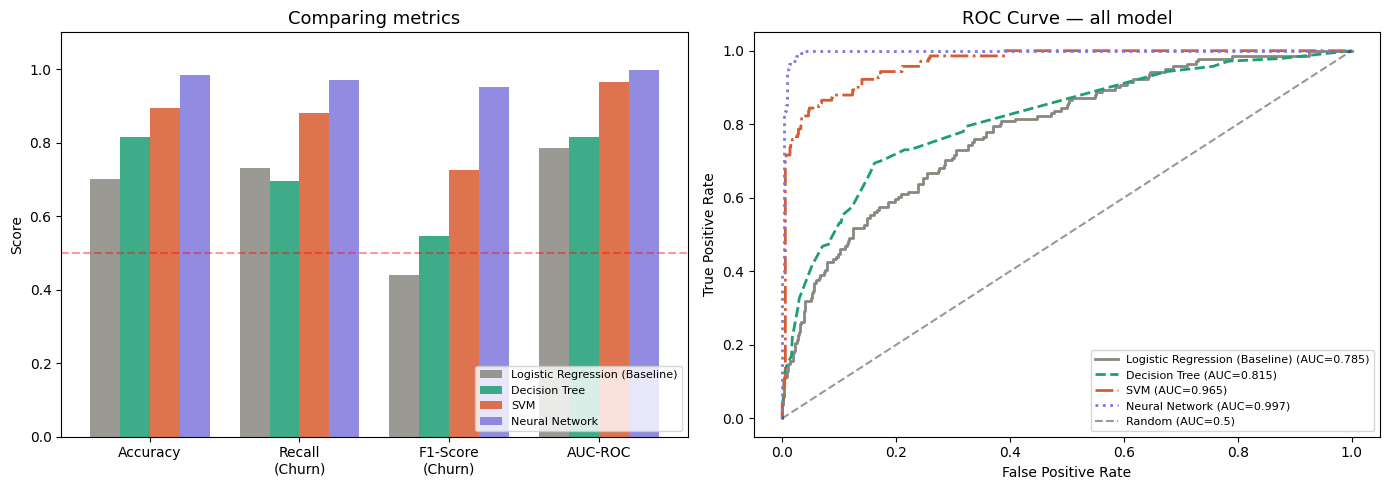

In [ ]:

# Bar chart comparing AUC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ["accuracy", "recall", "f1", "auc"]
metric_labels = ["Accuracy", "Recall\n(Churn)", "F1-Score\n(Churn)", "AUC-ROC"]
colors = ["#B5D4F4", "#85B7EB", "#378ADD", "#185FA5"]

x = np.arange(len(metrics))
width = 0.2
model_names = list(results.keys())
bar_colors = ["#888780", "#1D9E75", "#D85A30", "#7F77DD"]

for i, (name, r) in enumerate(results.items()):
    vals = [r[m] for m in metrics]
    axes[0].bar(x + i * width, vals, width, label=name, color=bar_colors[i], alpha=0.85)

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metric_labels, fontsize=10)
axes[0].set_ylim(0, 1.1)
axes[0].set_title("Comparing metrics", fontsize=13)
axes[0].legend(fontsize=8, loc='lower right')
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.4, label='Random baseline')
axes[0].set_ylabel("Score")

# ROC Curve all model
line_styles = ['-', '--', '-.', ':']
for i, (name, r) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    axes[1].plot(fpr, tpr,
                 label=f"{name} (AUC={r['auc']:.3f})",
                 color=bar_colors[i],
                 linestyle=line_styles[i],
                 lw=2)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC=0.5)')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — all model", fontsize=13)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

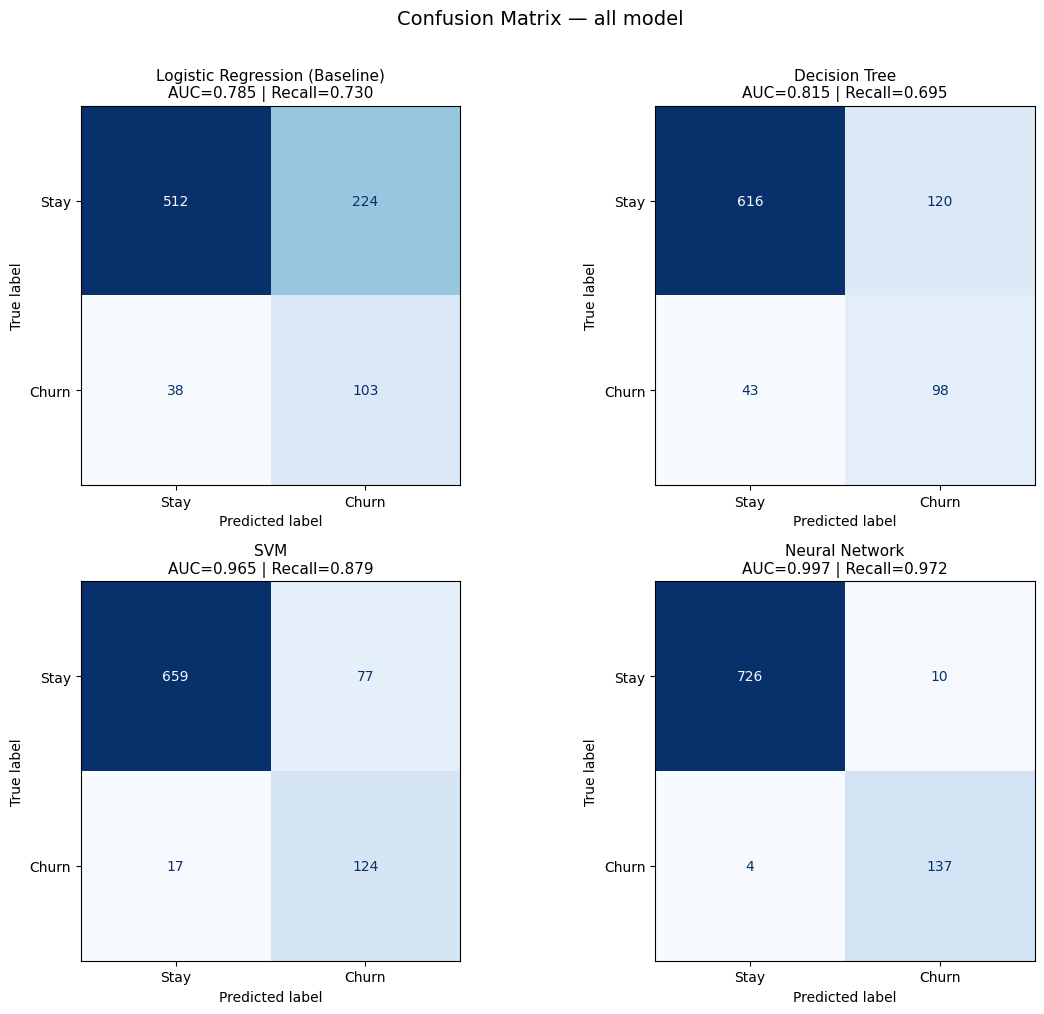

In [ ]:
# CONFUSION MATRIX — ALL MODEL

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, r["y_pred"]),
        display_labels=["Stay", "Churn"]
    ).plot(ax=axes[i], colorbar=False, cmap="Blues")
    axes[i].set_title(f"{name}\nAUC={r['auc']:.3f} | Recall={r['recall']:.3f}", fontsize=11)

plt.suptitle("Confusion Matrix — all model", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# CROSS-VALIDATION — BEST MODEL

best_name = max(results, key=lambda x: results[x]["auc"])
best_config = models[best_name]
best_model  = best_config["model"]

pipeline = Pipeline([('scaler', StandardScaler()), ('model', best_model)])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)

print(f"\n=== Cross-Validation AUC (5-fold) — {best_name} ===")
print(f"Each fold: {cv_scores.round(4)}")
print(f"Average: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


=== Cross-Validation AUC (5-fold) — Neural Network ===
Each fold: [0.9683 0.6453 0.9259 0.9505 0.9577]
Average: 0.8895 ± 0.1229


In [ ]:
# CROSS-VALIDATION FOR SVM
best_name = "SVM"
best_model = models["SVM"]["model"]
pipeline = Pipeline([('scaler', StandardScaler()), ('model', best_model)])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_svm = cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"Each fold: {cv_scores_svm.round(4)}")
print(f"Average: {cv_scores_svm.mean():.4f} ± {cv_scores_svm.std():.4f}")

Each fold: [0.9847 0.9616 0.9391 0.941  0.9568]
Average: 0.9566 ± 0.0165


In [ ]:
# CONCLUSION

print("\n" + "="*60)
print("CONCLUSION")
print("="*60)

for name, r in results.items():
    tag = " ← BEST" if name == best_name else ""
    print(f"  {name:<35} AUC={r['auc']:.4f} | Recall={r['recall']:.4f}{tag}")

print(f"""
Best Model: {best_name}
  - AUC-ROC:      {results[best_name]['auc']:.4f}
  - Recall(Churn): {results[best_name]['recall']:.4f}
  - F1(Churn):     {results[best_name]['f1']:.4f}

Baseline (Logistic Regression): AUC = {results['Logistic Regression (Baseline)']['auc']:.4f}
Best model compare to baseline: {results[best_name]['auc'] - results['Logistic Regression (Baseline)']['auc']:+.4f} AUC
""")


CONCLUSION
  Logistic Regression (Baseline)      AUC=0.7850 | Recall=0.7305
  Decision Tree                       AUC=0.8154 | Recall=0.6950
  SVM                                 AUC=0.9653 | Recall=0.8794 ← BEST
  Neural Network                      AUC=0.9968 | Recall=0.9716

Best Model: SVM
  - AUC-ROC:      0.9653
  - Recall(Churn): 0.8794
  - F1(Churn):     0.7251

Baseline (Logistic Regression): AUC = 0.7850
Best model compare to baseline: +0.1804 AUC

